 # Final Dataset: All Column Analysis



 This notebook profiles every column in the current ResearchLanka final dataset.

 It creates:



 - dataset overview

 - missing-value profile for every column

 - distinct-value profile for every column

 - top values for every column

 - numeric/date/year checks

 - multi-value column checks

 - source/type/language summary tables

 - CSV reports in the Kaggle working directory

In [3]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:  # pragma: no cover - only used outside notebooks
    display = print


pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")



 ## 1. Find And Load Dataset



 On Kaggle, click **Add Input** and attach your dataset. This notebook searches

 `/kaggle/input` automatically. Locally, it searches `data/processed/common`.

In [4]:
CANDIDATE_FILENAMES = [
    "common_publications_final_2016_2026_analysis_ready.csv",
    "common_publications_final_2016_2026_multivalue_normalized.csv",
    "common_publications_final_2016_2026_language_normalized.csv",
    "common_publications_final_2016_2026.csv",
    "common_publications_columns_filtered.csv",
    "common_publications_final.csv",
    "common_publications_deduplicated.csv"
]


def find_dataset() -> Path:
    search_roots = [
        Path("/kaggle/input"),
        Path("/kaggle/working"),
        Path("../data/processed/common"),
        Path("../input"),
    ]

    for filename in CANDIDATE_FILENAMES:
        for root in search_roots:
            if not root.exists():
                continue
            matches = sorted(root.rglob(filename))
            if matches:
                return matches[0]

    raise FileNotFoundError(
        "No final dataset found. Add the CSV to Kaggle input or set DATASET_PATH manually."
    )


DATASET_PATH = find_dataset()
OUTPUT_DIR = Path("/kaggle/working/final_dataset_column_analysis")
if not Path("/kaggle/working").exists():
    OUTPUT_DIR = Path("data/reports/final_dataset_column_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset: {DATASET_PATH}")
print(f"Reports: {OUTPUT_DIR}")



Dataset: ../data/processed/common/common_publications_deduplicated.csv
Reports: data/reports/final_dataset_column_analysis


In [5]:
def load_dataset(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path, dtype="object", low_memory=False)
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    raise ValueError(f"Unsupported dataset format: {path.suffix}")


df = load_dataset(DATASET_PATH)
df.columns = [str(column).strip() for column in df.columns]

print("Shape:", df.shape)
display(df.head(3))



Shape: (160344, 76)


,source_dataset,source_institution_id,source_record_id,source_datestamp,openalex_id,doi,url,landing_page_url,pdf_url,title,subtitle,original_title,abstract,keywords,publication_year,publication_date,created_date,published_date,type,subtype,publication_type,authors,author_count,author_names,author_affiliations,author_orcids,sri_lankan_authors,contributors,editors,institutions,sri_lankan_institutions,countries,publisher,publisher_location,journal,container_title,source_name,source_type,issn,issn_l,volume,issue,page,first_page,last_page,article_number,language,rights,license,license_url,oa_status,is_oa,cited_by_count,is_referenced_by_count,reference_count,referenced_works_count,references_json,concepts,topics,primary_topic,primary_field,primary_subfield,primary_domain,funder_name,funder_doi,funder_id,funder_award,event_name,event_acronym,event_location,event_start_date,event_end_date,event_sponsor,source_set_specs,raw_identifiers,raw_source_json
0,crossref,NaN,10.1002/9781118663219.wbegss081,NaN,NaN,10.1002/9781118663219.wbegss081,https://doi.org/10.1002/9781118663219.wbegss081,https://doi.org/10.1002/9781118663219.wbegss081,NaN,Cohabitation and Ekageikama in the Kandyan Kingdom (Sri Lanka),NaN,NaN,Cohabitation refers to a living arrangement where an unmarried couple lives together in a socially accepted union in...,NaN,2016,2016-04-21,2016-04-21,2016-04-21,other,NaN,other,Kalinga Tudor Silva,NaN,Kalinga Tudor Silva,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Wiley,NaN,The Wiley Blackwell Encyclopedia of Gender and Sexuality Studies,The Wiley Blackwell Encyclopedia of Gender and Sexuality Studies,The Wiley Blackwell Encyclopedia of Gender and Sexuality Studies,NaN,NaN,NaN,NaN,NaN,1-3,NaN,NaN,NaN,en,NaN,NaN,http://doi.wiley.com/10.1002/tdm_license_1.1,NaN,NaN,0,0,8,NaN,"{""DOI"": ""10.1007/BF01534287"", ""doi-asserted-by"": ""publisher"", ""key"": ""e_1_2_3_2_1""}; {""DOI"": ""10.2307/2801535"", ""art...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,crossref,NaN,10.1002/9781118663219.wbegss631,NaN,NaN,10.1002/9781118663219.wbegss631,https://doi.org/10.1002/9781118663219.wbegss631,https://doi.org/10.1002/9781118663219.wbegss631,NaN,Islam and Gender,NaN,NaN,Gender and sexuality in the Muslim world is decided both on interpretations of the Qur'an and on the respective soci...,NaN,2016,2016-04-21,2016-04-21,2016-04-21,other,NaN,other,Farzana Haniffa,NaN,Farzana Haniffa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Wiley,NaN,The Wiley Blackwell Encyclopedia of Gender and Sexuality Studies,The Wiley Blackwell Encyclopedia of Gender and Sexuality Studies,The Wiley Blackwell Encyclopedia of Gender and Sexuality Studies,NaN,NaN,NaN,NaN,NaN,1-5,NaN,NaN,NaN,en,NaN,NaN,http://doi.wiley.com/10.1002/tdm_license_1.1,NaN,NaN,2,2,14,NaN,"{""author"": ""Abu‐Lughod L."", ""key"": ""e_1_2_3_1_2_1"", ""volume-title"": ""Writing Women's Worlds: Bedouin Stories"", ""year...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,crossref,NaN,10.1002/9781119009924.eopr0063,NaN,NaN,10.1002/9781119009924.eopr0063,https://doi.org/10.1002/9781119009924.eopr0063,https://doi.org/10.1002/9781119009924.eopr0063,NaN,Buddhism,NaN,NaN,In this study Buddhism is presented from a point of view of the Buddha's own experience of freedom from the fundamen...,NaN,2021,2021-11-16,2021-11-16,2021-11-16,other,NaN,other,Asanga Tilakaratne,NaN,Asanga Tilakaratne,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Wiley,NaN,The Encyclopedia of Philosophy of Religion,The Encyclopedia of Philosophy of Religion,The Encyclopedia of Philosophy of Religion,NaN,NaN,NaN,NaN,NaN,1-11,NaN,NaN,NaN,en,NaN,NaN,http://doi.wiley.com/10.1002/tdm_license_1.1,NaN,NaN,0,0,9,NaN,"{""author"": ""Bodhi Bhikkhu"", ""key"": ""e_1_2_6_1_2_1"", ""volume-title"": ""The Connected Discourses of the Buddha: A Trans...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


 ## 2. Helpers

In [6]:
BLANK_STRINGS = {"", "nan", "none", "null", "na", "n/a", "[]", "{}"}
MULTIVALUE_SEPARATOR = ";"


def clean_text(value):
    if pd.isna(value):
        return ""
    return " ".join(str(value).split()).strip()


def nonblank_mask(series: pd.Series) -> pd.Series:
    normalized = series.astype("string").str.strip().str.lower()
    return normalized.notna() & ~normalized.isin(BLANK_STRINGS)


def example_values(series: pd.Series, limit: int = 3) -> str:
    values = []
    for value in series[nonblank_mask(series)].drop_duplicates().head(limit):
        text = clean_text(value)
        if len(text) > 80:
            text = text[:77] + "..."
        values.append(text)
    return " | ".join(values)


def infer_column_role(column: str) -> str:
    lower = column.lower()
    if lower in {"publication_year", "author_count", "citation_count", "reference_count"}:
        return "numeric"
    if lower.endswith("_count") or "difference" in lower:
        return "numeric"
    if "date" in lower or lower.endswith("datestamp"):
        return "date"
    if lower in {"doi", "openalex_id", "url", "pdf_url", "issn", "issn_l"}:
        return "identifier"
    if lower in {"title", "abstract", "keywords"}:
        return "text"
    if lower in {"authors", "institutions", "countries", "concepts", "topics"}:
        return "multi_value"
    if lower in {"type", "source_type", "language", "license", "oa_status", "is_oa"}:
        return "category"
    return "metadata"



 ## 3. Dataset Overview

In [7]:
overview = pd.DataFrame(
    [
        {"metric": "dataset_path", "value": str(DATASET_PATH)},
        {"metric": "rows", "value": len(df)},
        {"metric": "columns", "value": len(df.columns)},
        {"metric": "memory_mb", "value": round(df.memory_usage(deep=True).sum() / 1024**2, 2)},
        {"metric": "duplicate_doi_values", "value": int(df["doi"].duplicated().sum()) if "doi" in df else None},
        {
            "metric": "duplicate_title_year_values",
            "value": int(df.duplicated(["title", "publication_year"]).sum())
            if {"title", "publication_year"}.issubset(df.columns)
            else None,
        },
    ]
)
display(overview)
overview.to_csv(OUTPUT_DIR / "dataset_overview.csv", index=False)



,metric,value
0,dataset_path,../data/processed/common/common_publications_deduplicated.csv
1,rows,160344
2,columns,76
3,memory_mb,1627.71
4,duplicate_doi_values,74446
5,duplicate_title_year_values,4102


 ## 4. Column Profile For Every Column

In [8]:
profile_rows = []
for position, column in enumerate(df.columns, start=1):
    series = df[column]
    present = nonblank_mask(series)
    present_values = series[present].astype(str).str.strip()
    string_lengths = present_values.str.len()
    multivalue_count = (
        int(present_values.str.contains(MULTIVALUE_SEPARATOR, regex=False).sum())
        if len(present_values)
        else 0
    )

    profile_rows.append(
        {
            "position": position,
            "column": column,
            "role": infer_column_role(column),
            "present_rows": int(present.sum()),
            "missing_rows": int((~present).sum()),
            "coverage_pct": round(float(present.mean() * 100), 2),
            "missing_pct": round(float((~present).mean() * 100), 2),
            "distinct_values": int(present_values.nunique(dropna=True)),
            "multivalue_rows": multivalue_count,
            "multivalue_present_pct": round(multivalue_count / len(present_values) * 100, 2)
            if len(present_values)
            else 0.0,
            "min_length": int(string_lengths.min()) if len(string_lengths) else 0,
            "max_length": int(string_lengths.max()) if len(string_lengths) else 0,
            "examples": example_values(series),
        }
    )

column_profile = pd.DataFrame(profile_rows)
display(column_profile)
column_profile.to_csv(OUTPUT_DIR / "column_profile.csv", index=False)



,position,column,role,present_rows,missing_rows,coverage_pct,missing_pct,distinct_values,multivalue_rows,multivalue_present_pct,min_length,max_length,examples
0,1,source_dataset,metadata,160344,0,100.00,0.00,7,30699,19.15,8,38,crossref | crossref; repositories_combined | crossref; sljol; repositories_combined
1,2,source_institution_id,metadata,108093,52251,67.41,32.59,55,966,0.89,3,17,sliit | ruh | uom
2,3,source_record_id,metadata,160344,0,100.00,0.00,160344,7393,4.61,11,422,10.1002/9781118663219.wbegss081 | 10.1002/9781118663219.wbegss631 | 10.1002/9781119009924.eopr0063
3,4,source_datestamp,date,108093,52251,67.41,32.59,91233,3197,2.96,20,277,2026-02-15T05:19:04Z | 2026-02-15T05:13:38Z | 2026-02-15T05:22:08Z
4,5,openalex_id,identifier,0,160344,0.00,100.00,0,0,0.00,0,0,
5,6,doi,identifier,85897,74447,53.57,46.43,85897,0,0.00,11,86,10.1002/9781118663219.wbegss081 | 10.1002/9781118663219.wbegss631 | 10.1002/9781119009924.eopr0063
6,7,url,identifier,160310,34,99.98,0.02,159452,0,0.00,11,362,https://doi.org/10.1002/9781118663219.wbegss081 | https://doi.org/10.1002/9781118663219.wbegss631 | https://doi.org/...
7,8,landing_page_url,metadata,160310,34,99.98,0.02,159452,0,0.00,11,362,https://doi.org/10.1002/9781118663219.wbegss081 | https://doi.org/10.1002/9781118663219.wbegss631 | https://doi.org/...
8,9,pdf_url,identifier,0,160344,0.00,100.00,0,0,0.00,0,0,
9,10,title,text,160224,120,99.93,0.07,150757,1806,1.13,1,4776,Cohabitation and Ekageikama in the Kandyan Kingdom (Sri Lanka) | Islam and Gender | Buddhism


 ## 5. Missingness Plot

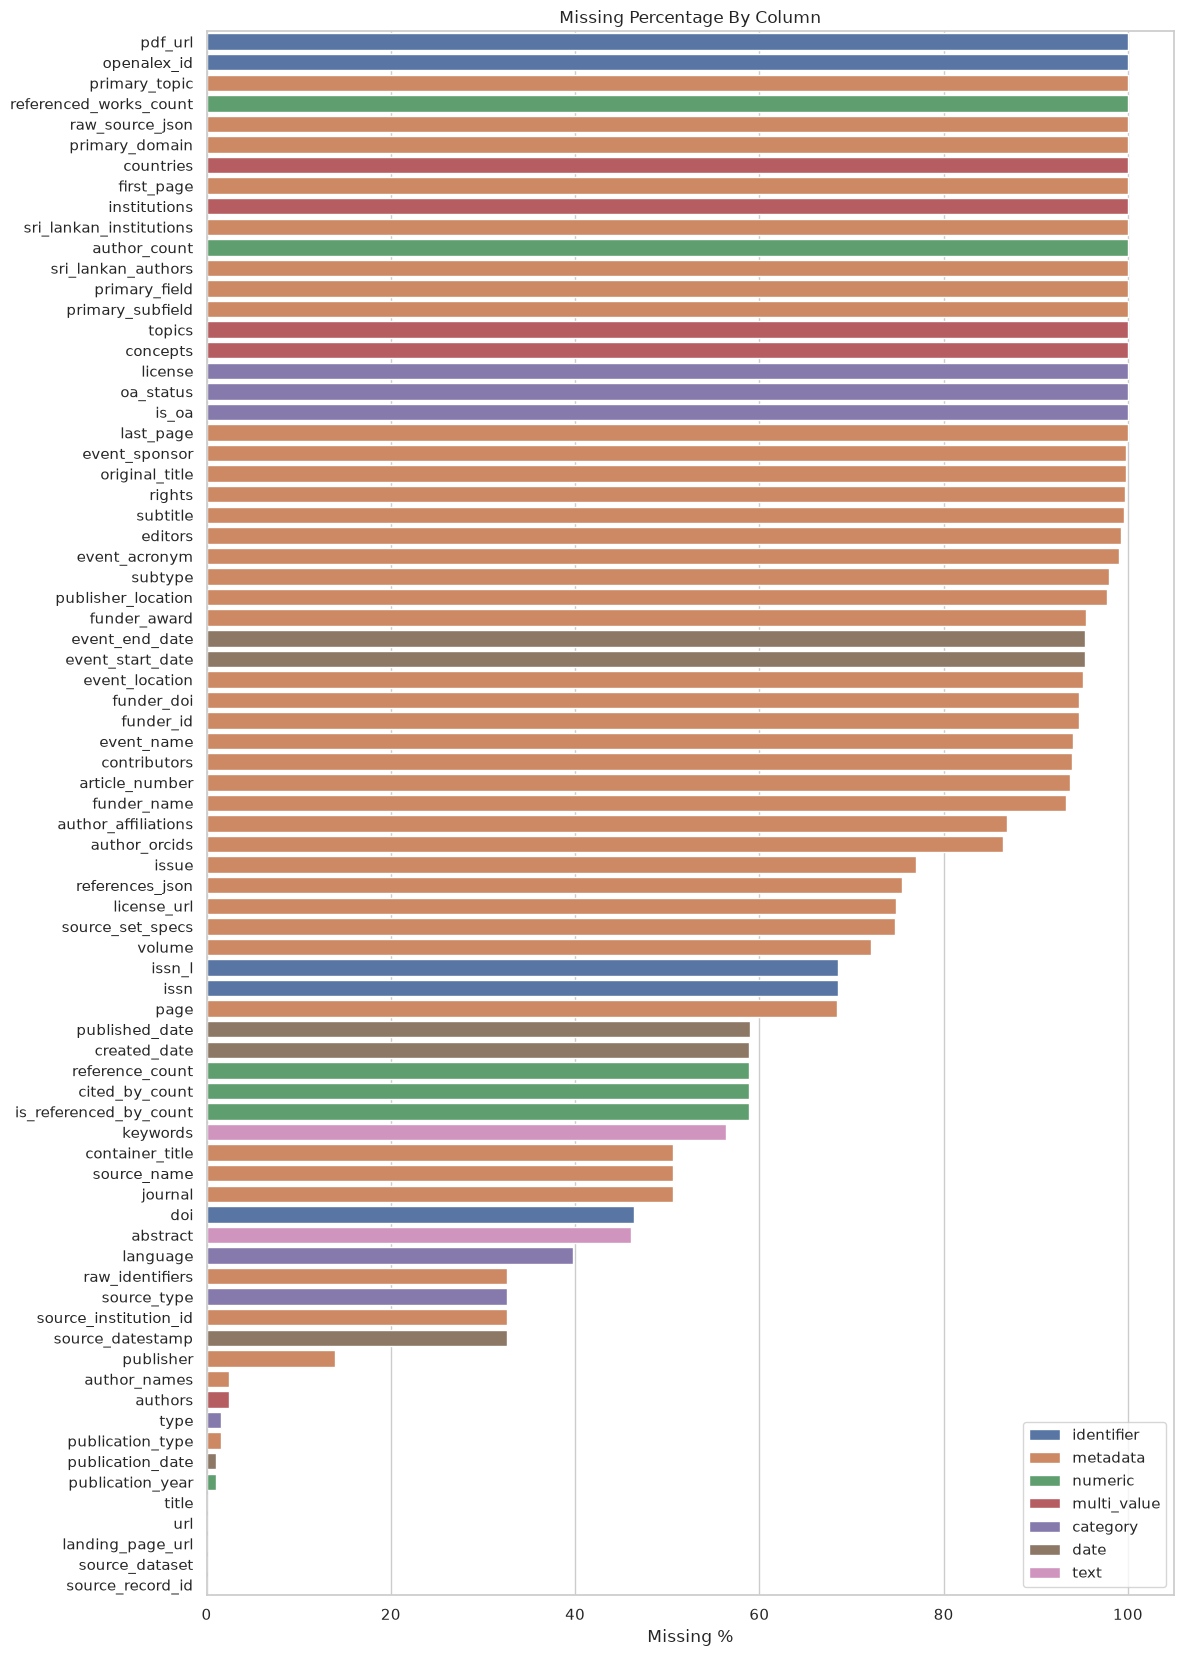

In [9]:
plot_df = column_profile.sort_values("missing_pct", ascending=False)
plt.figure(figsize=(12, max(8, len(plot_df) * 0.22)))
sns.barplot(data=plot_df, y="column", x="missing_pct", hue="role", dodge=False)
plt.title("Missing Percentage By Column")
plt.xlabel("Missing %")
plt.ylabel("")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "missing_percentage_by_column.png", dpi=160)
plt.show()



 ## 6. Top Values For Every Column

In [10]:
top_value_rows = []
for column in df.columns:
    series = df[column].copy()
    values = series.astype("string").str.strip()
    values = values.mask(values.str.lower().isin(BLANK_STRINGS), pd.NA)
    counts = values.value_counts(dropna=True).head(20)
    for rank, (value, count) in enumerate(counts.items(), start=1):
        top_value_rows.append(
            {
                "column": column,
                "rank": rank,
                "value": value,
                "rows": int(count),
                "pct_of_dataset": round(count / len(df) * 100, 3),
            }
        )

top_values = pd.DataFrame(top_value_rows)
display(top_values.head(100))
top_values.to_csv(OUTPUT_DIR / "top_values_by_column.csv", index=False)



,column,rank,value,rows,pct_of_dataset
0,source_dataset,1,repositories_combined,77394,48.267
1,source_dataset,2,crossref,52251,32.587
2,source_dataset,3,sljol; repositories_combined,16958,10.576
3,source_dataset,4,crossref; sljol; repositories_combined,9129,5.693
4,source_dataset,5,crossref; repositories_combined,4499,2.806
5,source_dataset,6,crossref; repositories_combined; sljol,67,0.042
6,source_dataset,7,repositories_combined; sljol,46,0.029
7,source_institution_id,1,sljol,25785,16.081
8,source_institution_id,2,uom,16149,10.071
9,source_institution_id,3,nsf,15093,9.413


 ## 7. Numeric Column Checks

In [11]:
numeric_candidate_columns = [
    column
    for column in df.columns
    if infer_column_role(column) == "numeric" or column in {"publication_year", "author_count"}
]

numeric_rows = []
for column in numeric_candidate_columns:
    numeric = pd.to_numeric(df[column], errors="coerce")
    numeric_rows.append(
        {
            "column": column,
            "numeric_rows": int(numeric.notna().sum()),
            "non_numeric_or_missing_rows": int(numeric.isna().sum()),
            "min": numeric.min(),
            "median": numeric.median(),
            "mean": numeric.mean(),
            "max": numeric.max(),
        }
    )

numeric_profile = pd.DataFrame(numeric_rows)
display(numeric_profile)
numeric_profile.to_csv(OUTPUT_DIR / "numeric_profile.csv", index=False)



,column,numeric_rows,non_numeric_or_missing_rows,min,median,mean,max
0,publication_year,158709,1635,1924.0,2019.0,2016.070109,2099.0
1,author_count,0,160344,NaN,NaN,NaN,NaN
2,cited_by_count,65946,94398,0.0,1.0,8.028402,9432.0
3,is_referenced_by_count,65946,94398,0.0,1.0,8.028402,9432.0
4,reference_count,65946,94398,0.0,15.0,27.438556,3671.0
5,referenced_works_count,0,160344,NaN,NaN,NaN,NaN


 ## 8. Year Analysis

,metric,value
0,min_year,1924.0
1,max_year,2099.0
2,missing_or_invalid_year,1635.0
3,before_2016,47453.0
4,after_2026,3.0


,publication_year,rows
0,1924,1
1,1928,22
2,1930,17
3,1931,15
4,1932,23
5,1933,18
6,1935,16
7,1936,19
8,1937,17
9,1938,20


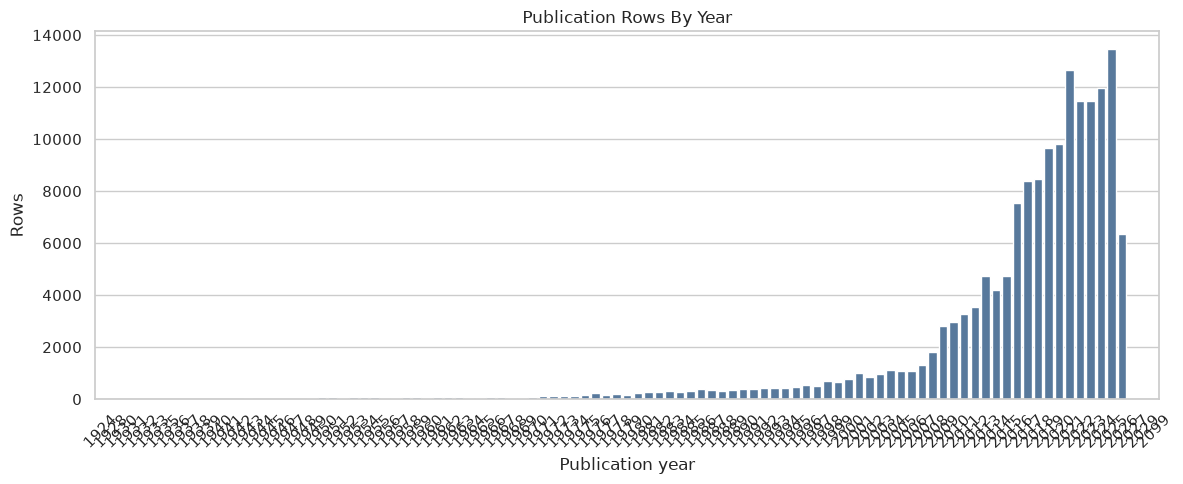

In [12]:
if "publication_year" in df.columns:
    years = pd.to_numeric(df["publication_year"], errors="coerce")
    year_summary = pd.DataFrame(
        [
            {"metric": "min_year", "value": years.min()},
            {"metric": "max_year", "value": years.max()},
            {"metric": "missing_or_invalid_year", "value": int(years.isna().sum())},
            {"metric": "before_2016", "value": int((years < 2016).sum())},
            {"metric": "after_2026", "value": int((years > 2026).sum())},
        ]
    )
    display(year_summary)
    year_summary.to_csv(OUTPUT_DIR / "year_summary.csv", index=False)

    year_counts = years.dropna().astype(int).value_counts().sort_index().reset_index()
    year_counts.columns = ["publication_year", "rows"]
    display(year_counts)
    year_counts.to_csv(OUTPUT_DIR / "year_counts.csv", index=False)

    plt.figure(figsize=(12, 5))
    sns.barplot(data=year_counts, x="publication_year", y="rows", color="#4C78A8")
    plt.xticks(rotation=45)
    plt.title("Publication Rows By Year")
    plt.xlabel("Publication year")
    plt.ylabel("Rows")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "publication_rows_by_year.png", dpi=160)
    plt.show()



 ## 9. Important Category Distributions

,type,rows,pct
0,journal-article,64963,40.51
1,Article,33808,21.08
2,Other,9888,6.17
3,proceedings-article,9496,5.92
4,Thesis,5516,3.44
5,book-chapter,4267,2.66
6,Conference-Full-text,3876,2.42
7,Exam Paper,3619,2.26
8,posted-content,3322,2.07
9,Thesis-Abstract,3067,1.91


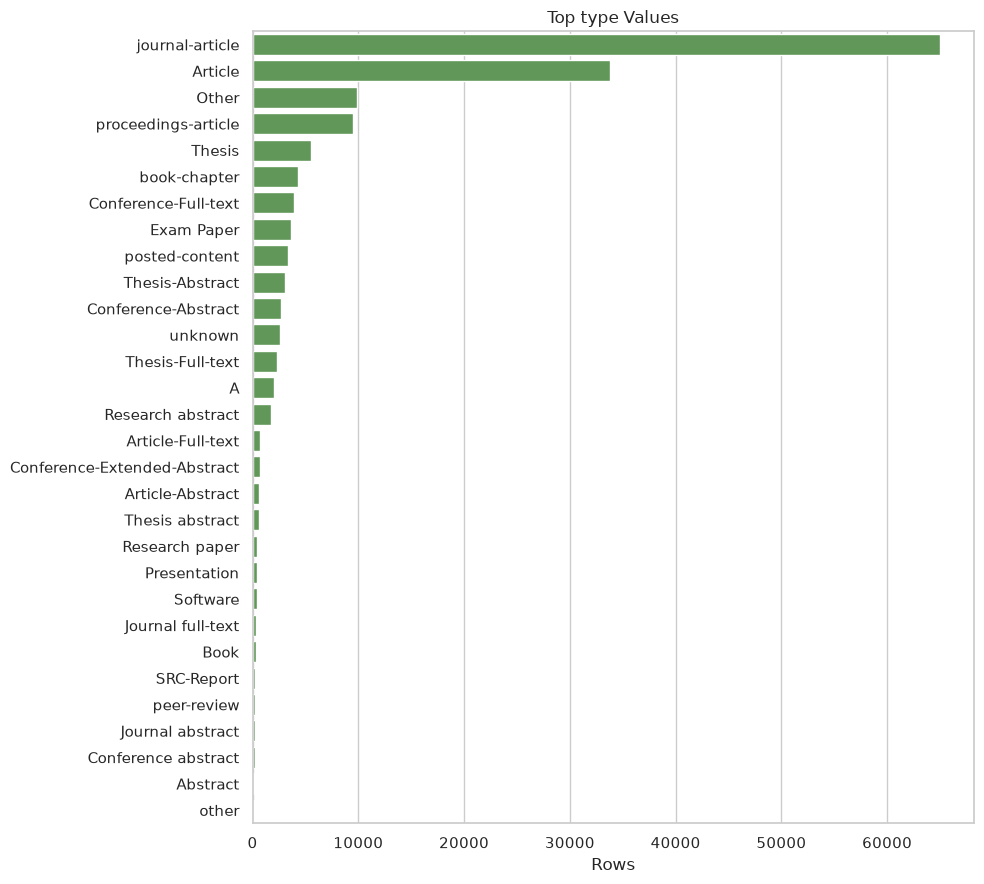

,source_type,rows,pct
0,repository,82006,51.14
1,unknown,52251,32.59
2,journal,26087,16.27


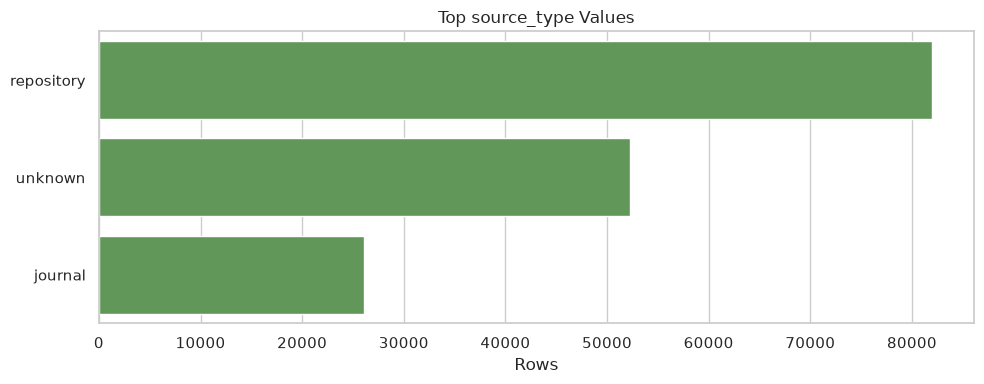

,language,rows,pct
0,en,80069,49.94
1,unknown,63855,39.82
2,en_US,10912,6.81
3,other,4120,2.57
4,si_lk,1102,0.69
5,ng,69,0.04
6,si,34,0.02
7,ar,32,0.02
8,fr,23,0.01
9,fa,23,0.01


/tmp/ipykernel_269173/123319543.py:38: UserWarning: Glyph 3523 (\N{SINHALA LETTER DANTAJA SAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_269173/123319543.py:38: UserWarning: Glyph 3524 (\N{SINHALA LETTER HAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_269173/123319543.py:38: UserWarning: Glyph 3517 (\N{SINHALA LETTER DANTAJA LAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_269173/123319543.py:39: UserWarning: Glyph 3523 (\N{SINHALA LETTER DANTAJA SAYANNA}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT_DIR / f"{column}_top_values.png", dpi=160)
/tmp/ipykernel_269173/123319543.py:39: UserWarning: Glyph 3524 (\N{SINHALA LETTER HAYANNA}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT_DIR / f"{column}_top_values.png", dpi=160)
/tmp/ipykernel_269173/123319543.py:39: UserWarning: Glyph 3517 (\N{SINHALA LETTER DANTAJA LAYANNA}) missing from font(s) DejaVu Sans.
  plt.savefig(OUTPUT_

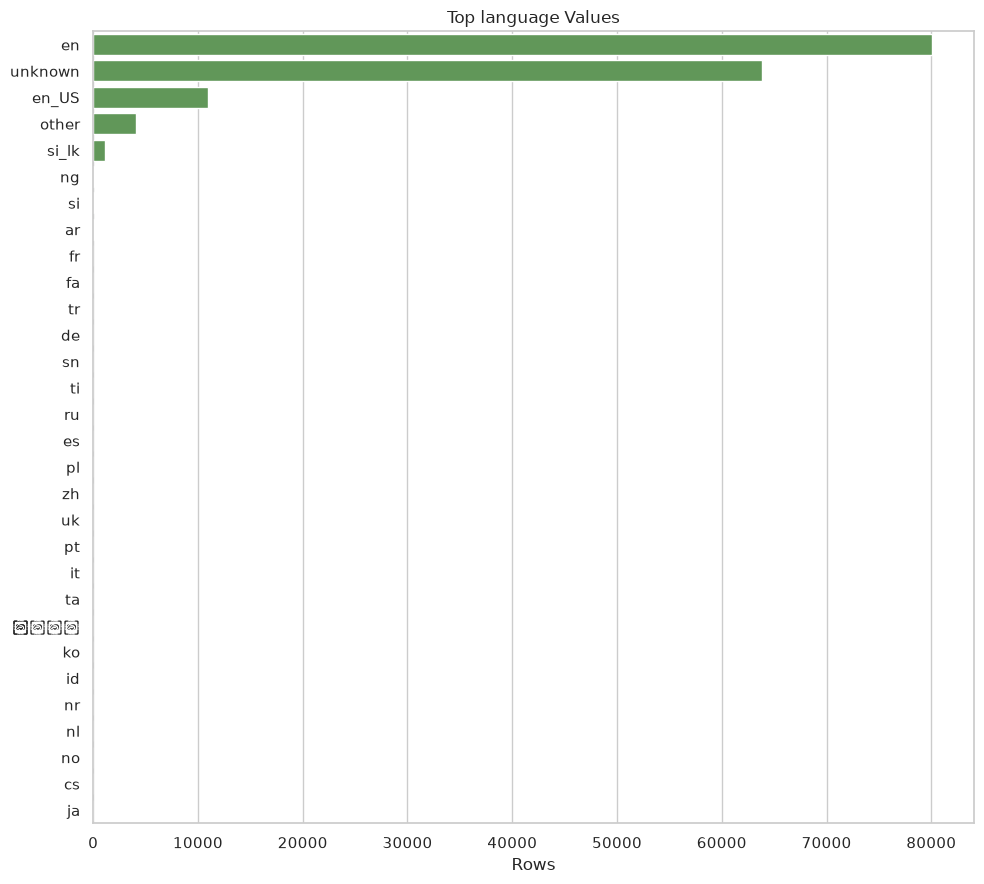

,license,rows,pct
0,unknown,160344,100.0


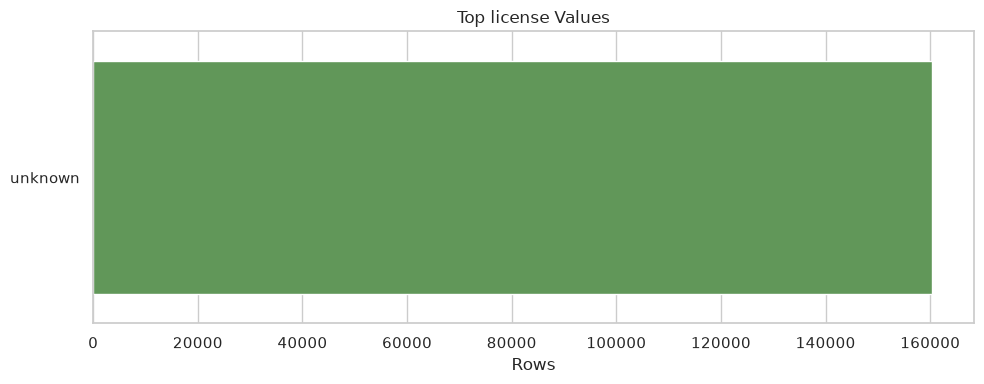

,oa_status,rows,pct
0,unknown,160344,100.0


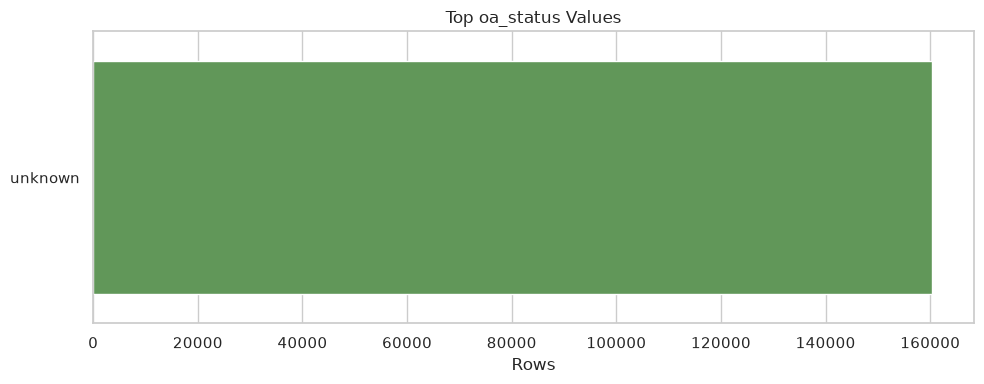

,is_oa,rows,pct
0,unknown,160344,100.0


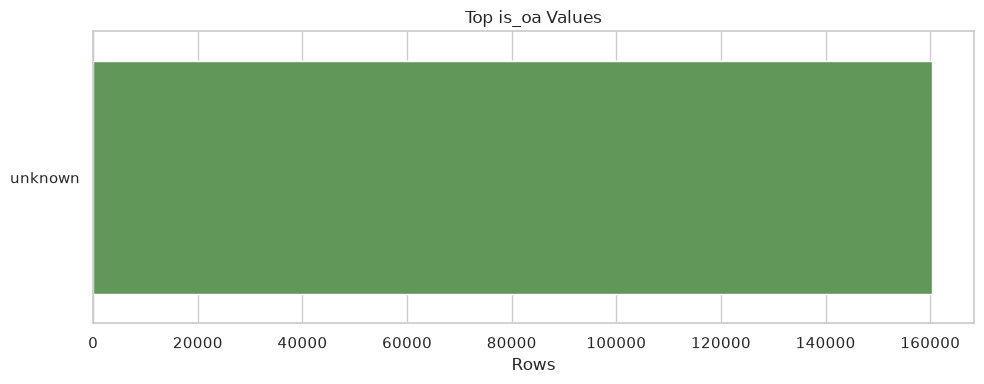

,primary_domain,rows,pct
0,unknown,160344,100.0


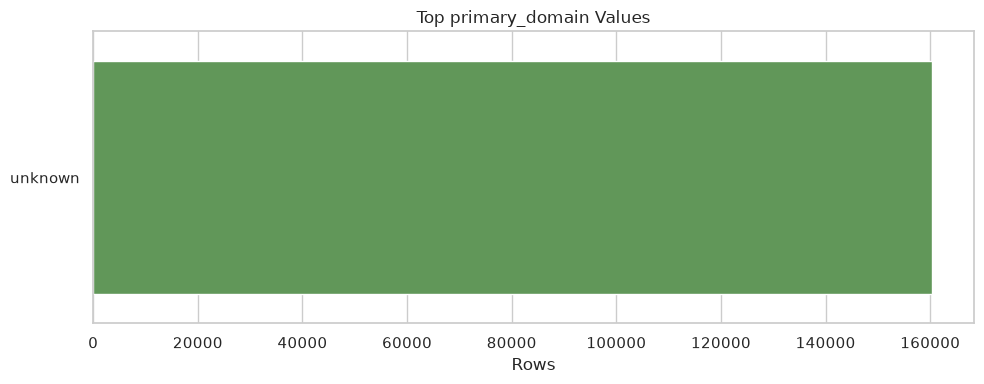

,primary_field,rows,pct
0,unknown,160344,100.0


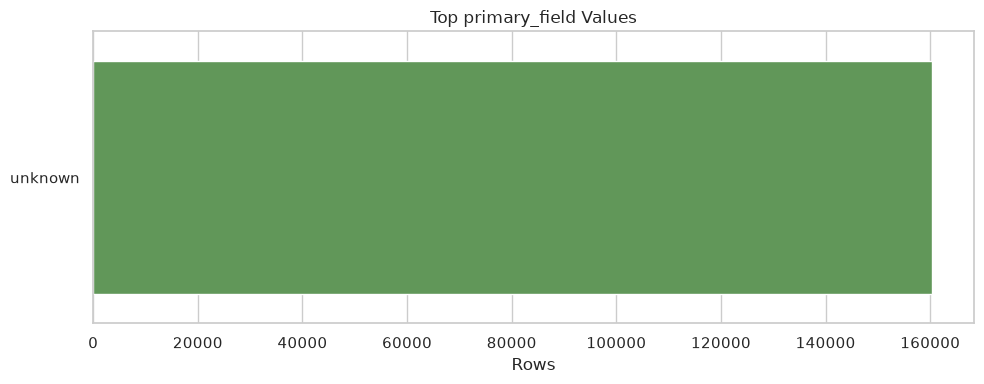

,source_dataset,rows,pct
0,repositories_combined,77394,48.27
1,crossref,52251,32.59
2,sljol; repositories_combined,16958,10.58
3,crossref; sljol; repositories_combined,9129,5.69
4,crossref; repositories_combined,4499,2.81
5,crossref; repositories_combined; sljol,67,0.04
6,repositories_combined; sljol,46,0.03


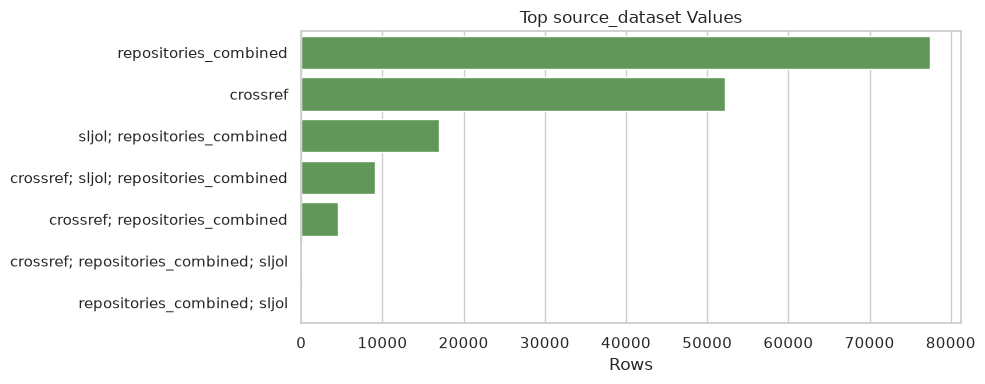

In [13]:
category_columns = [
    column
    for column in [
        "type",
        "source_type",
        "language",
        "license",
        "oa_status",
        "is_oa",
        "primary_domain",
        "primary_field",
        "source_dataset",
    ]
    if column in df.columns
]

for column in category_columns:
    counts = (
        df[column]
        .astype("string")
        .str.strip()
        .mask(lambda value: value.str.lower().isin(BLANK_STRINGS), pd.NA)
        .fillna("unknown")
        .value_counts()
        .head(30)
        .reset_index()
    )
    counts.columns = [column, "rows"]
    counts["pct"] = (counts["rows"] / len(df) * 100).round(2)
    display(counts)
    counts.to_csv(OUTPUT_DIR / f"{column}_counts.csv", index=False)

    plt.figure(figsize=(10, max(4, min(10, len(counts) * 0.3))))
    sns.barplot(data=counts, y=column, x="rows", color="#59A14F")
    plt.title(f"Top {column} Values")
    plt.xlabel("Rows")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{column}_top_values.png", dpi=160)
    plt.show()



 ## 10. Multi-Value Column Analysis

In [14]:
multi_value_columns = [
    "source_dataset",
    "authors",
    "keywords",
    "author_affiliations",
    "author_orcids",
    "sri_lankan_authors",
    "contributors",
    "institutions",
    "sri_lankan_institutions",
    "countries",
    "issn",
    "concepts",
    "topics",
    "funder_name",
    "funder_doi",
    "funder_identifier",
    "funder_award",
    "source_set_specs",
    "raw_identifiers",
]
multi_value_columns = [column for column in multi_value_columns if column in df.columns]

multi_rows = []
for column in multi_value_columns:
    values = df[column][nonblank_mask(df[column])].astype(str)
    item_counts = values.map(lambda value: len([item for item in value.split(";") if item.strip()]))
    multi_rows.append(
        {
            "column": column,
            "present_rows": int(len(values)),
            "rows_with_multiple_values": int((item_counts > 1).sum()),
            "multi_value_present_pct": round((item_counts > 1).mean() * 100, 2)
            if len(item_counts)
            else 0,
            "mean_items_per_present_row": round(item_counts.mean(), 2) if len(item_counts) else 0,
            "max_items_in_one_row": int(item_counts.max()) if len(item_counts) else 0,
        }
    )

multi_value_profile = pd.DataFrame(multi_rows)
display(multi_value_profile)
multi_value_profile.to_csv(OUTPUT_DIR / "multi_value_profile.csv", index=False)



,column,present_rows,rows_with_multiple_values,multi_value_present_pct,mean_items_per_present_row,max_items_in_one_row
0,source_dataset,160344,30699,19.15,1.25,3
1,authors,156349,104707,66.97,4.09,2463
2,keywords,69861,63005,90.19,4.17,57
3,author_affiliations,20970,14982,71.44,3.87,383
4,author_orcids,21659,10983,50.71,2.82,284
5,sri_lankan_authors,0,0,0.00,0.00,0
6,contributors,9724,3884,39.94,1.70,8
7,institutions,0,0,0.00,0.00,0
8,sri_lankan_institutions,0,0,0.00,0.00,0
9,countries,0,0,0.00,0.00,0


 ## 11. Coverage By Source Type

In [15]:
if "source_type" in df.columns:
    coverage_rows = []
    for source_type, group in df.groupby(df["source_type"].fillna("unknown")):
        for column in df.columns:
            coverage_rows.append(
                {
                    "source_type": source_type,
                    "column": column,
                    "rows": len(group),
                    "present_rows": int(nonblank_mask(group[column]).sum()),
                    "coverage_pct": round(nonblank_mask(group[column]).mean() * 100, 2),
                }
            )

    coverage_by_source_type = pd.DataFrame(coverage_rows)
    display(coverage_by_source_type.head(100))
    coverage_by_source_type.to_csv(OUTPUT_DIR / "coverage_by_source_type.csv", index=False)



,source_type,column,rows,present_rows,coverage_pct
0,journal,source_dataset,26087,26087,100.00
1,journal,source_institution_id,26087,26087,100.00
2,journal,source_record_id,26087,26087,100.00
3,journal,source_datestamp,26087,26087,100.00
4,journal,openalex_id,26087,0,0.00
5,journal,doi,26087,26087,100.00
6,journal,url,26087,26087,100.00
7,journal,landing_page_url,26087,26087,100.00
8,journal,pdf_url,26087,0,0.00
9,journal,title,26087,26083,99.98


 ## 12. Quality Flags

In [16]:
quality = {}
if "title" in df.columns:
    quality["missing_title"] = int((~nonblank_mask(df["title"])).sum())
if "doi" in df.columns:
    doi_present = nonblank_mask(df["doi"])
    quality["doi_present"] = int(doi_present.sum())
    quality["duplicate_doi_rows"] = int(df.loc[doi_present, "doi"].duplicated().sum())
if {"title", "publication_year"}.issubset(df.columns):
    title_year_present = nonblank_mask(df["title"]) & nonblank_mask(df["publication_year"])
    quality["duplicate_title_year_rows"] = int(
        df.loc[title_year_present].duplicated(["title", "publication_year"]).sum()
    )
if "abstract" in df.columns:
    quality["missing_abstract"] = int((~nonblank_mask(df["abstract"])).sum())
if "language" in df.columns:
    quality["unknown_language"] = int(df["language"].fillna("").astype(str).str.strip().eq("unknown").sum())

quality_flags = pd.DataFrame([{"metric": key, "value": value} for key, value in quality.items()])
display(quality_flags)
quality_flags.to_csv(OUTPUT_DIR / "quality_flags.csv", index=False)



,metric,value
0,missing_title,120
1,doi_present,85897
2,duplicate_doi_rows,0
3,duplicate_title_year_rows,3973
4,missing_abstract,73932
5,unknown_language,0


 ## 13. Report Files

In [17]:
report_files = sorted(OUTPUT_DIR.glob("*"))
display(pd.DataFrame({"report_file": [str(path) for path in report_files]}))
print(f"Saved {len(report_files)} report files to {OUTPUT_DIR}")


,report_file
0,data/reports/final_dataset_column_analysis/column_profile.csv
1,data/reports/final_dataset_column_analysis/coverage_by_source_type.csv
2,data/reports/final_dataset_column_analysis/dataset_overview.csv
3,data/reports/final_dataset_column_analysis/is_oa_counts.csv
4,data/reports/final_dataset_column_analysis/is_oa_top_values.png
5,data/reports/final_dataset_column_analysis/language_counts.csv
6,data/reports/final_dataset_column_analysis/language_top_values.png
7,data/reports/final_dataset_column_analysis/license_counts.csv
8,data/reports/final_dataset_column_analysis/license_top_values.png
9,data/reports/final_dataset_column_analysis/missing_percentage_by_column.png


Saved 29 report files to data/reports/final_dataset_column_analysis
